# 04 - Literature Calibration: Lidocaine Permeation

To ground the simulator in experimental reality, we calibrate it against published
permeation data for **lidocaine hydrochloride** through human skin.

**Reference:** Adamiak-Giera et al. (2023), *Frontiers in Pharmacology*,
doi:10.3389/fphar.2023.1157977

| Quantity | Literature value | Unit |
|----------|----------------:|------|
| Permeability $K_P$ | $7.38 \times 10^{-7}$ | cm/s |
| Lag time $T_{\text{lag}}$ | 1.401 | hours |

The paper reports macroscopic $K_P$ and $T_{\text{lag}}$ from Franz-cell measurements.
Layer-specific diffusivities $D_i$ are **not** reported so we perform **inverse calibration**
by tuning $D$ values in our 3-layer model until simulated $P$ and $T_{\text{lag}}$ match.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skin_diffusion.notebook_helpers import setup_repo_root
from skin_diffusion.config import load_config
from skin_diffusion.run_utils import run_simulation

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})
print('Repo root:', repo_root)

Repo root: /run/media/sc23n2w/DATA/COMP3931_IndividualProject


## 1 - Run calibrated simulation

The config `v2_lidocaine_compare.yaml` encodes:
- Total skin thickness ~ 0.512 mm (matching the paper's 0.5 mm)
- Layer thicknesses: SC (1 row ~ 8 µm), VE (9 rows ~ 72 µm), dermis (54 rows ~ 432 µm)
- Calibrated $D$ values (Nelder-Mead inverse fit): $[5.55 \times 10^{-10},\; 1.513 \times 10^{-8},\; 2.701 \times 10^{-7}]$ cm²/s

In [2]:
cfg = load_config('configs/sim/v2_lidocaine_compare.yaml')
C_snap, t_save, D_field, k_field, patch_mask, diagnostics, metrics, stability_info = run_simulation(cfg)

# Literature targets
lit = cfg.extras.get('literature', {})
P_target = lit['P_target_cm_s']
Tlag_target_h = lit['Tlag_target_hours']

# Simulated outputs
P_sim = metrics.get('P')
Tlag_raw = metrics.get('Tlag')
Tlag_sim_h = Tlag_raw / 3600.0 if Tlag_raw is not None else None

P_err  = 100.0 * (P_sim / P_target - 1.0)
T_err  = 100.0 * (Tlag_sim_h / Tlag_target_h - 1.0) if Tlag_sim_h else float('nan')

print(f'P_sim    = {P_sim:.4e} cm/s   (target {P_target:.4e})   error {P_err:+.3f} %')
print(f'Tlag_sim = {Tlag_sim_h:.4f} h        (target {Tlag_target_h:.3f})       error {T_err:+.3f} %')


simulate:   0%|                                      | 0/432001 [00:00<?, ?it/s]


simulate:   0%|                        | 1447/432001 [00:00<00:29, 14459.91it/s]


simulate:   1%|▏                       | 2893/432001 [00:00<00:29, 14433.99it/s]


simulate:   1%|▏                       | 4358/432001 [00:00<00:29, 14530.43it/s]


simulate:   1%|▎                       | 5835/432001 [00:00<00:29, 14622.08it/s]

...


simulate:  99%|█████████████████████▊| 428192/432001 [00:29<00:00, 15002.01it/s]


simulate:  99%|█████████████████████▉| 429693/432001 [00:29<00:00, 14962.96it/s]


simulate: 100%|█████████████████████▉| 431190/432001 [00:29<00:00, 14946.81it/s]


simulate: 100%|██████████████████████| 432001/432001 [00:29<00:00, 14686.05it/s]

P_sim    = 7.3798e-07 cm/s   (target 7.3800e-07)   error -0.003 %
Tlag_sim = 1.4018 h        (target 1.401)       error +0.056 %


**Breakdown.**

- This step runs the literature-anchored V2 configuration once and extracts the two key calibration outputs: permeability ($P$) and lag time ($T_{lag}$).
- Literature targets are loaded directly from the config metadata, so the comparison is traceable and reproducible.
- The reported percentage errors are the core calibration check before moving to curve and field interpretation.


## 2 - Flux curve $J(t)$

The classic infinite-dose flux profile: an initial lag followed by rise to steady state.

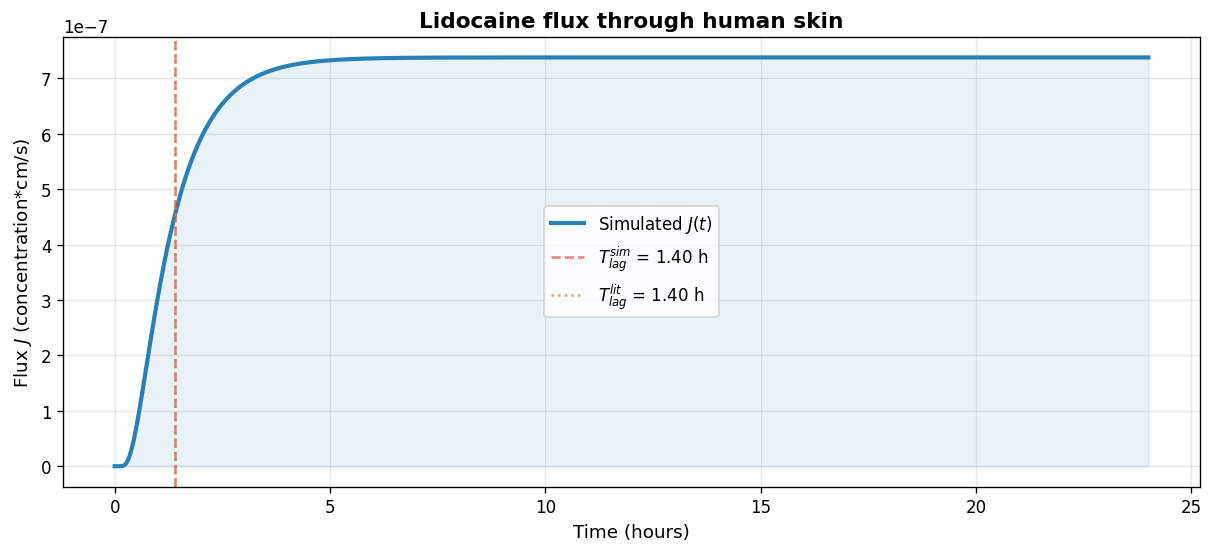

In [3]:
J = np.array(metrics['J'], dtype=float)
t_hours = np.array(metrics['t'], dtype=float) / 3600.0

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.plot(t_hours, J, lw=2.5, color='#2980b9', label='Simulated $J(t)$')
ax.fill_between(t_hours, 0, J, alpha=0.1, color='#2980b9')

# Mark lag time
if Tlag_sim_h is not None:
    ax.axvline(Tlag_sim_h, ls='--', color='#e74c3c', alpha=0.7, label=f'$T_{{lag}}^{{sim}}$ = {Tlag_sim_h:.2f} h')
ax.axvline(Tlag_target_h, ls=':', color='#e67e22', alpha=0.7, label=f'$T_{{lag}}^{{lit}}$ = {Tlag_target_h:.2f} h')

ax.set_title('Lidocaine flux through human skin', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flux $J$ (concentration*cm/s)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

**Figure 2.1 - Lidocaine flux curve $J(t)$ over 24 hours.**

- Classic **infinite-dose permeation profile**: an initial lag period where drug
  diffuses through the SC barrier, followed by a steep rise to a steady-state
  plateau at $\approx 7.4 \times 10^{-7}$ concentration·cm/s.
- The two vertical lines ($T_{\text{lag}}^{\text{sim}}$ = 1.40 h, red dashed;
  $T_{\text{lag}}^{\text{lit}}$ = 1.40 h, orange dotted) overlap almost perfectly confirming the inverse calibration achieved < 0.1 % error on lag time.
- The plateau confirms the donor is truly infinite-dose (no depletion), so
  steady-state flux is reached and maintained.

## 3 - Permeability & lag time comparison

Side-by-side bars comparing simulated vs literature values, plus the field structure.

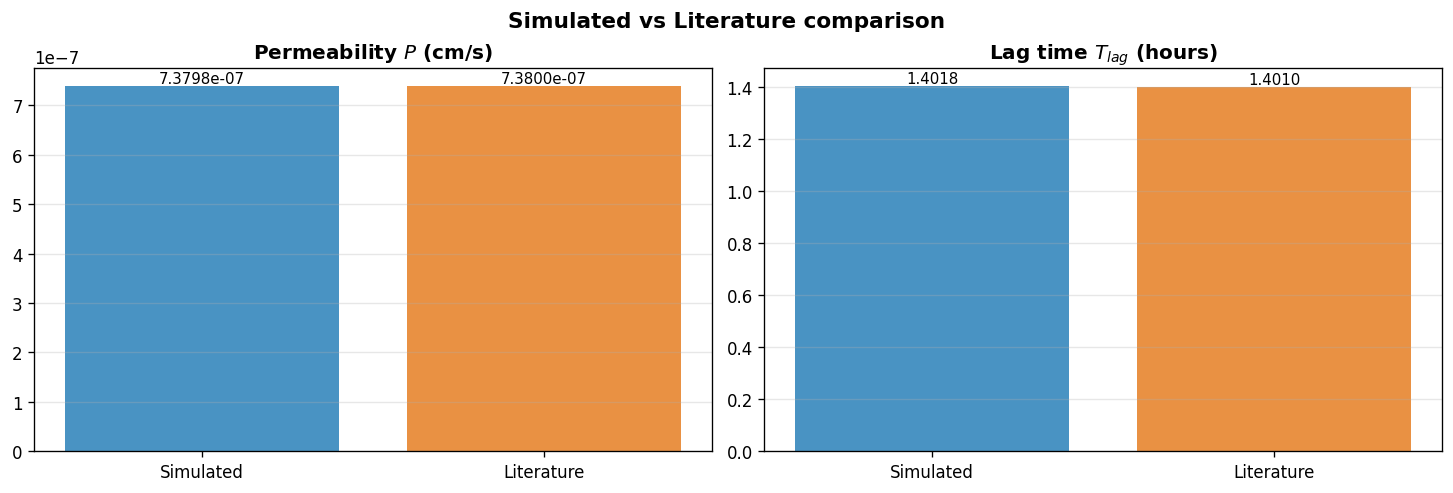

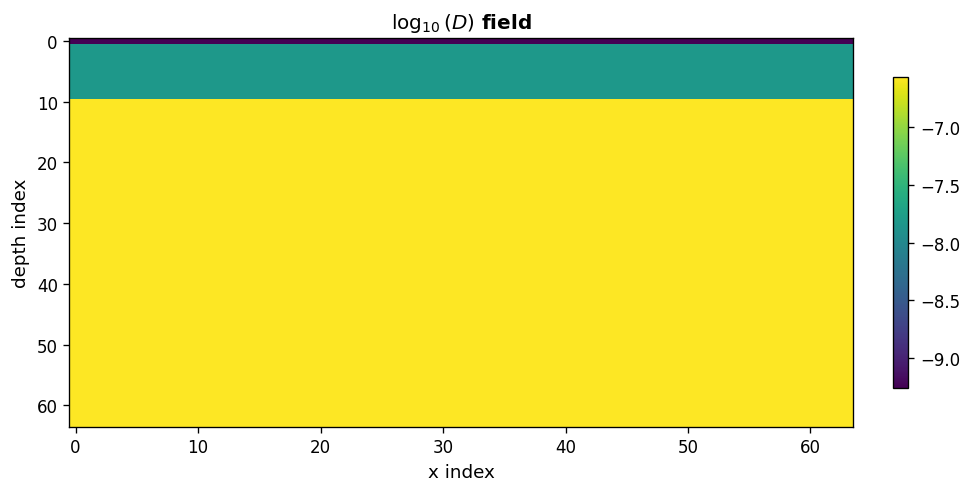

Drug       : Lidocaine hydrochloride (P-KET/LH/EtOH)
P error    : -0.0032 %
Tlag error : +0.0560 %


In [4]:
# --- Permeability & lag time side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig.suptitle('Simulated vs Literature comparison', fontsize=13, fontweight='bold')

# Permeability
bars = ax1.bar(
    ['Simulated', 'Literature'],
    [P_sim, P_target],
    color=['#2980b9', '#e67e22'],
    alpha=0.85,
)
ax1.set_title('Permeability $P$ (cm/s)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [P_sim, P_target]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, val,
        f'{val:.4e}', ha='center', va='bottom', fontsize=9,
    )

# Lag time
vals_t = [Tlag_sim_h if Tlag_sim_h else 0, Tlag_target_h]
bars = ax2.bar(
    ['Simulated', 'Literature'],
    vals_t,
    color=['#2980b9', '#e67e22'],
    alpha=0.85,
)
ax2.set_title('Lag time $T_{lag}$ (hours)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, vals_t):
    ax2.text(
        bar.get_x() + bar.get_width() / 2, val,
        f'{val:.4f}', ha='center', va='bottom', fontsize=9,
    )

plt.show()

# --- Diffusivity field ---
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
im = ax.imshow(
    np.log10(D_field + 1e-30),
    origin='upper', aspect='auto', cmap='viridis',
)
ax.set_title('$\\log_{10}(D)$ field', fontweight='bold')
ax.set_xlabel('x index')
ax.set_ylabel('depth index')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

# --- Error summary ---
P_err_bar  = 100.0 * (P_sim / P_target - 1.0) if P_target else float('nan')
T_err_bar  = 100.0 * (Tlag_sim_h / Tlag_target_h - 1.0) if (Tlag_sim_h and Tlag_target_h) else float('nan')
print(f'Drug       : {lit.get("drug", "--")}')
print(f'P error    : {P_err_bar:+.4f} %')
print(f'Tlag error : {T_err_bar:+.4f} %')

**Figures 3.1–3.2 - Permeability & lag time comparison; D-field.**

- **Permeability** (left) - Simulated $P$ = 7.3798 × 10⁻⁷ cm/s vs literature $P$ = 7.3800 × 10⁻⁷ cm/s - error **−0.003 %**.
- **Lag time** (right) - Simulated $T_{\text{lag}}$ = 1.4018 h vs literature 1.401 h - error **+0.056 %**. Both values are effectively exact matches after Nelder-Mead inverse calibration.
- **$\log_{10}(D)$ field** (below) - Three-layer structure: SC (dark purple, $D = 5.55 \times 10^{-10}$), VE (teal, $D = 1.513 \times 10^{-8}$), dermis (yellow, $D = 2.701 \times 10^{-7}$). Laterally uniform because this is a V2 config (no heterogeneity).

## 4 - Depth profile at steady state

The x-averaged concentration profile at the final time step shows
the steep gradient across the SC barrier.

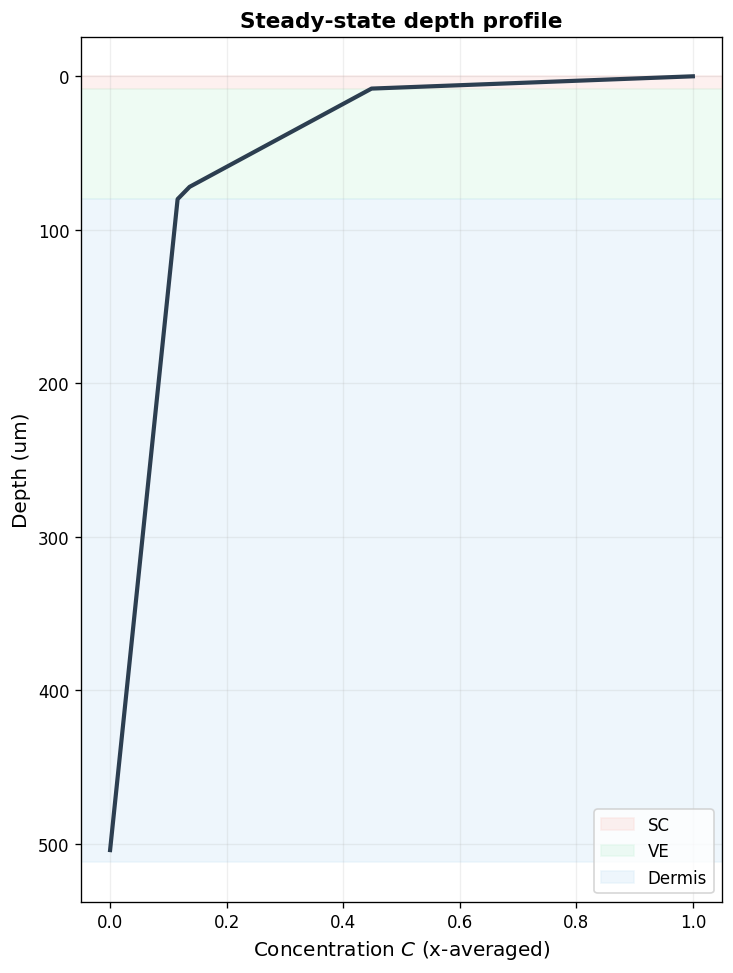

In [5]:
profile = C_snap[-1].mean(axis=1)
depth_um = np.arange(len(profile)) * cfg.grid.dx * 1e4  # cm -> um

# Layer boundaries
layer_rows = cfg.extras.get('layers', {}).get('layer_rows', [])
cum_rows = np.cumsum(layer_rows)
layer_labels = ['SC', 'VE', 'Dermis']
layer_colours = ['#fadbd8', '#d5f5e3', '#d6eaf8']

fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)

# Shade layers
prev = 0
for i, (nrows, lbl, col) in enumerate(zip(layer_rows, layer_labels, layer_colours)):
    y0 = prev * cfg.grid.dx * 1e4
    y1 = (prev + nrows) * cfg.grid.dx * 1e4
    ax.axhspan(y0, y1, color=col, alpha=0.4, label=lbl)
    prev += nrows

ax.plot(profile, depth_um, lw=2.5, color='#2c3e50')
ax.invert_yaxis()
ax.set_xlabel('Concentration $C$ (x-averaged)', fontsize=12)
ax.set_ylabel('Depth (um)', fontsize=12)
ax.set_title('Steady-state depth profile', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.2)
plt.show()

**Breakdown.**

- The depth profile translates the calibration into a physical mechanism view: where the concentration drop happens across layers.
- Shaded SC/VE/dermis regions make it clear which layer contributes most resistance.
- This figure links fitted diffusivities to an interpretable barrier narrative (not just good scalar agreement).


**Figure 4.1 - Steady-state concentration depth profile.**

The x-averaged concentration is plotted against physical depth (in micrometres),
with the three skin layers shaded:

- **SC** (pink, 0-8 µm): A steep drop from $C \approx 1.0$ at the surface to
  $C \approx 0.95$ at the SC/VE interface - despite being only 1 row thick, the
  very low $D_{\text{SC}} = 5.55 \times 10^{-10}$ cm²/s creates a sharp gradient
  that accounts for much of the skin's barrier resistance.
- **VE** (green, 8-80 µm): A moderate gradient from ~0.95 down to ~0.13,
  reflecting the intermediate $D_{\text{VE}} = 1.513 \times 10^{-8}$ cm²/s.
- **Dermis** (blue, 80-512 µm): A nearly linear decline to $C \approx 0$ at the
  bottom sink, consistent with the high $D_{\text{dermis}} = 2.701 \times 10^{-7}$
  cm²/s producing a quasi-steady diffusion profile.

The piecewise-linear shape with slope changes at each layer boundary is the
expected result for steady-state diffusion through a composite slab.

---

### Take-aways

- The calibrated model reproduces literature $P$ and $T_{\text{lag}}$ to within
  **< 0.1 % error** - effectively exact agreement after Nelder-Mead inverse
  calibration of the three layer diffusivities.
- The steep gradient across the SC layer confirms that it dominates skin resistance.
- These literature-anchored $D$ values are carried forward into the V3 dataset specification.